In [35]:
import requests
import json
import time

def tradingview_internacional(symbol, exchange=None):
    """
    Busca dados de ativos internacionais no TradingView
    """
    try:
        print(f"🔍 Buscando {symbol}...")
        
        # Mapeamento de bolsas internacionais comuns
        exchange_map = {
            # ETFs EUA
            'VOO': 'AMEX',      # Vanguard S&P 500 ETF
            'SPY': 'NYSE',      # SPDR S&P 500 ETF
            'QQQ': 'NASDAQ',    # Invesco QQQ Trust
            'IWM': 'NYSE',      # iShares Russell 2000 ETF
            'EEM': 'NYSE',      # iShares MSCI Emerging Markets ETF
            
            # Ações EUA
            'AAPL': 'NASDAQ',
            'MSFT': 'NASDAQ',
            'TSLA': 'NASDAQ',
            'AMZN': 'NASDAQ',
            'GOOGL': 'NASDAQ',
            'META': 'NASDAQ',
            'NFLX': 'NASDAQ',
            'NVDA': 'NASDAQ',
            
            # ETFs e Ações específicas que você mencionou
            'RGTI': 'NASDAQ',   # Rigetti Computing
            # Adicione outros símbolos conforme necessidade
        }
        
        # Determina a bolsa
        if exchange:
            bolsa = exchange
        elif symbol.upper() in exchange_map:
            bolsa = exchange_map[symbol.upper()]
        else:
            # Tenta descobrir automaticamente
            bolsa = descobrir_bolsa(symbol)
            if not bolsa:
                print(f"❌ {symbol} - Bolsa não identificada, tentando NASDAQ...")
                bolsa = "NASDAQ"  # Fallback
        
        # Constrói o ticker completo
        ticker_completo = f"{bolsa}:{symbol.upper()}"
        
        print(f"   📊 Bolsa: {bolsa}")
        
        # API do TradingView (global)
        url = "https://scanner.tradingview.com/global/scan"
        
        payload = {
            "symbols": {
                "tickers": [ticker_completo],
                "query": {"types": []}
            },
            "columns": [
                "name", "close", "change", "change_abs", "volume", 
                "market_cap_basic", "price_earnings_ttm", 
                "sector", "description",
                
                # Dados históricos
                "close|1", "close|5", "close|1M", "close|1Y",
                "change|1", "change|5", "change|1M", "change|1Y",
                
                # Dados adicionais para internacionais
                "dividend_yield", "beta_1_year", "total_assets"
            ]
        }
        
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
            'Content-Type': 'application/json',
            'Origin': 'https://www.tradingview.com',
            'Referer': 'https://www.tradingview.com/'
        }
        
        response = requests.post(url, json=payload, headers=headers, timeout=15)
        
        if response.status_code == 200:
            data = response.json()
            
            if data.get('data'):
                item = data['data'][0]
                dados_brutos = item['d']
                
                # Mapeia os dados
                dados = {
                    'symbol': item['s'],
                    'nome': dados_brutos[0],
                    'preco_atual': dados_brutos[1],
                    'variacao_dia_percentual': dados_brutos[2],
                    'variacao_dia_absoluta': dados_brutos[3],
                    'volume': dados_brutos[4],
                    'market_cap': dados_brutos[5],
                    'p_l': dados_brutos[6],
                    'setor': dados_brutos[7],
                    'descricao': dados_brutos[8],
                    
                    # Fechamentos históricos
                    'fechamento_1d_atras': dados_brutos[9],
                    'fechamento_1w_atras': dados_brutos[10],
                    'fechamento_1m_atras': dados_brutos[11],
                    'fechamento_1y_atras': dados_brutos[12],
                    
                    # Variações
                    'variacao_1d': dados_brutos[13],
                    'variacao_1w': dados_brutos[14],
                    'variacao_1m': dados_brutos[15],
                    'variacao_1y': dados_brutos[16],
                    
                    # Dados específicos de ETFs/ações internacionais
                    'dividend_yield': dados_brutos[17] if len(dados_brutos) > 17 else None,
                    'beta': dados_brutos[18] if len(dados_brutos) > 18 else None,
                    'total_assets': dados_brutos[19] if len(dados_brutos) > 19 else None,
                    
                    'exchange': bolsa,
                    'moeda': 'USD'  # Assume USD para internacionais
                }
                
                print(f"✅ {symbol} - {dados['nome']}")
                print(f"   💰 Preço: ${dados['preco_atual']:.2f}")
                print(f"   📈 Variação: {dados['variacao_dia_percentual']:.2f}%")
                print(f"   🏢 Setor: {dados.get('setor', 'N/A')}")
                
                return dados
            else:
                print(f"❌ {symbol} - Não encontrado na bolsa {bolsa}")
                return None
        else:
            print(f"❌ {symbol} - Erro HTTP {response.status_code}")
            return None
            
    except Exception as e:
        print(f"❌ {symbol} - Erro: {e}")
        return None

def descobrir_bolsa(symbol):
    """
    Tenta descobrir automaticamente a bolsa do símbolo
    """
    # Lista de bolsas para tentar (em ordem de probabilidade)
    bolsas_tentativas = ["NASDAQ", "NYSE", "AMEX", "BATS", "OTC", "TSX", "LSE"]
    
    for bolsa in bolsas_tentativas:
        print(f"   🔍 Tentando bolsa {bolsa} para {symbol}...")
        try:
            url = "https://scanner.tradingview.com/global/scan"
            payload = {
                "symbols": {"tickers": [f"{bolsa}:{symbol.upper()}"]},
                "columns": ["name"]
            }
            
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
                'Content-Type': 'application/json'
            }
            
            response = requests.post(url, json=payload, headers=headers, timeout=5)
            
            if response.status_code == 200:
                data = response.json()
                if data.get('data'):
                    print(f"   🔍 {symbol} encontrado na {bolsa}")
                    return bolsa
        except:
            continue
    
    return None


def buscar_ativos_internacionais(symbols):
    """
    Busca dados de múltiplos ativos internacionais
    """
    print("🌎 BUSCANDO ATIVOS INTERNACIONAIS")
    print("=" * 60)
    
    resultados = {}
    
    for symbol in symbols:
        dados = tradingview_internacional(symbol)
        if dados is not None:
            resultados[symbol] = dados
            mostrar_resumo_internacional(dados)
        print("-" * 50)
        time.sleep(1)  # Respeitar rate limiting
    
    return resultados

def mostrar_resumo_internacional(dados):
    """
    Mostra resumo formatado para ativos internacionais
    """
    if not dados:
        return
    
    print(f"\n📊 {dados['symbol']} - {dados['nome']}")
    print(f"   💰 Preço atual: ${dados['preco_atual']:.2f} {dados['moeda']}")
    print(f"   📈 Hoje: {dados['variacao_dia_percentual']:+.2f}%")
    print(f"   🏢 Bolsa: {dados['exchange']}")
    
    if dados.get('dividend_yield'):
        print(f"   💵 Dividend Yield: {dados['dividend_yield']:.2f}%")
    
    print(f"\n   📅 Histórico:")
    periodos = [
        ("1 Dia", dados.get('fechamento_1d_atras'), dados.get('variacao_1d')),
        ("1 Semana", dados.get('fechamento_1w_atras'), dados.get('variacao_1w')),
        ("1 Mês", dados.get('fechamento_1m_atras'), dados.get('variacao_1m')),
        ("1 Ano", dados.get('fechamento_1y_atras'), dados.get('variacao_1y')),
    ]
    
    for periodo, fechamento, variacao in periodos:
        if fechamento and variacao:
            sinal = "📈" if variacao > 0 else "📉"
            print(f"      {periodo:8} | ${fechamento:8.2f} | {variacao:+.2f}% {sinal}")

In [36]:
import pandas as pd
path_bases = '/home/lucas/MEGA/ML_and_DS/trading/bases_stocks'

def load_stooq(symbol, atualizar=False):
    try:
        df = pd.read_pickle(f'{path_bases}/df_tratado_{symbol}.pkl') 
        if atualizar:
            raise FileNotFoundError
    except FileNotFoundError:
        url = f"https://stooq.com/q/d/l/?s={symbol}&i=d"
        df = pd.read_csv(url)
        
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date').sort_index()
        df = df.dropna()
        # reset index renomaeando date para time 
        df.reset_index(inplace=True)
        # renomear colunas para minusculo
        df.columns = [col.lower() for col in df.columns]
        df.rename(columns={'date': 'time'}, inplace=True)

        # SALVAR O DATAFRAME TRATADO PARA USO FUTURO
        df.to_pickle(f'{path_bases}/df_tratado_{symbol}.pkl')

    
    return df




In [37]:
# Lista de ativos internacionais para buscar
ativos_internacionais = [
    'RGTI',    # Rigetti Computing
    'VOO',     # Vanguard S&P 500 ETF
    'SPY',     # SPDR S&P 500 ETF
    'QQQ',     # Invesco QQQ Trust
    'AAPL',    # Apple
    'MSFT',    # Microsoft
    'TSLA',    # Tesla
]

# Executar busca
resultados_internacionais = buscar_ativos_internacionais(ativos_internacionais)

print(f"\n📈 RESUMO: {len(resultados_internacionais)}/{len(ativos_internacionais)} ativos internacionais encontrados")

🌎 BUSCANDO ATIVOS INTERNACIONAIS
🔍 Buscando RGTI...
   📊 Bolsa: NASDAQ
✅ RGTI - RGTI
   💰 Preço: $16.09
   📈 Variação: 7.34%
   🏢 Setor: Electronic Technology

📊 NASDAQ:RGTI - RGTI
   💰 Preço atual: $16.09 USD
   📈 Hoje: +7.34%
   🏢 Bolsa: NASDAQ

   📅 Histórico:
      1 Dia    | $   16.07 | +0.31% 📈
      1 Semana | $   16.07 | -0.12% 📉
      1 Mês    | $   16.09 | -11.45% 📉
--------------------------------------------------
🔍 Buscando VOO...
   📊 Bolsa: AMEX
✅ VOO - VOO
   💰 Preço: $626.89
   📈 Variação: 0.06%
   🏢 Setor: Miscellaneous

📊 AMEX:VOO - VOO
   💰 Preço atual: $626.89 USD
   📈 Hoje: +0.06%
   🏢 Bolsa: AMEX

   📅 Histórico:
      1 Dia    | $  626.86 | +0.01% 📈
      1 Semana | $  626.86 | +0.02% 📈
      1 Mês    | $  626.89 | -1.47% 📉
--------------------------------------------------
🔍 Buscando SPY...
   📊 Bolsa: NYSE
❌ SPY - Não encontrado na bolsa NYSE
--------------------------------------------------
🔍 Buscando QQQ...
   📊 Bolsa: NASDAQ
✅ QQQ - QQQ
   💰 Preço: $601.92

In [38]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [39]:
# ler dados da tesla na funcao tradingview_internacional
symbols = {
    # "USO": "uso.us",
    "AAPL": "aapl.us",
    "SMH": "smh.us",
    "SPY": "spy.us"
}

symbol = "AAPL"

atualizar = True
data = {name: load_stooq(ticker, atualizar=atualizar) for name, ticker in symbols.items()}

# exemplo
data[symbol].tail()
summary = tradingview_internacional(symbol)
df = data[symbol].copy()[-2500:]
print(summary)
df

🔍 Buscando AAPL...
   📊 Bolsa: NASDAQ
✅ AAPL - AAPL
   💰 Preço: $255.78
   📈 Variação: -2.27%
   🏢 Setor: Electronic Technology
{'symbol': 'NASDAQ:AAPL', 'nome': 'AAPL', 'preco_atual': 255.78, 'variacao_dia_percentual': -2.273335116341274, 'variacao_dia_absoluta': -5.950000000000017, 'volume': 56289683, 'market_cap': 3755141881356, 'p_l': 32.36164882714643, 'setor': 'Electronic Technology', 'descricao': 'Apple Inc.', 'fechamento_1d_atras': 255.79, 'fechamento_1w_atras': 255.79, 'fechamento_1m_atras': 255.78, 'fechamento_1y_atras': None, 'variacao_1d': -0.0781280518770331, 'variacao_1w': -0.2509033534633218, 'variacao_1m': -1.425928780638206, 'variacao_1y': None, 'dividend_yield': None, 'beta': 1.3319893, 'total_assets': 379297000000, 'exchange': 'NASDAQ', 'moeda': 'USD'}


,time,open,high,low,close,volume
7940,2016-03-08,22.8465,23.0704,22.7580,22.9024,134221830
7941,2016-03-09,22.9685,23.0313,22.7288,22.9242,106824387
7942,2016-03-10,22.9908,23.1757,22.7033,22.9361,147837245
7943,2016-03-11,23.1757,23.1845,23.0127,23.1805,111758808
7944,2016-03-14,23.1031,23.3298,23.0723,23.2396,110617132
...,...,...,...,...,...,...
10435,2026-02-09,277.9050,278.2000,271.7000,274.6200,44623396
10436,2026-02-10,274.8850,275.3700,272.9400,273.6800,34376898
10437,2026-02-11,274.6950,280.1800,274.4500,275.5000,51931283
10438,2026-02-12,275.5900,275.7200,260.1800,261.7300,81077229


In [40]:
import ta
df['time'] = pd.to_datetime(df['time']) 

# colocar todos os indicadores de ta
df['volume_mfi'] = ta.volume.MFIIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=14,
    fillna=True
).money_flow_index()
df['momentum_rsi'] = ta.momentum.RSIIndicator(
    close=df['close'],
    window=14,
    fillna=True
).rsi()
df['volatility_bbp'] = ta.volatility.BollingerBands(
    close=df['close'],
    window=20,  
    window_dev=2,
    fillna=True
).bollinger_pband()
df['trend_macd_diff'] = ta.trend.MACD(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9,
    fillna=True
).macd_diff()*100  # escalar para facilitar o treinamento
df['volatility_bbp'] = df['volatility_bbp']*100-50  # centrar em 0
  
train_df, test_df = train_test_split(df, test_size=0.05, shuffle=False)

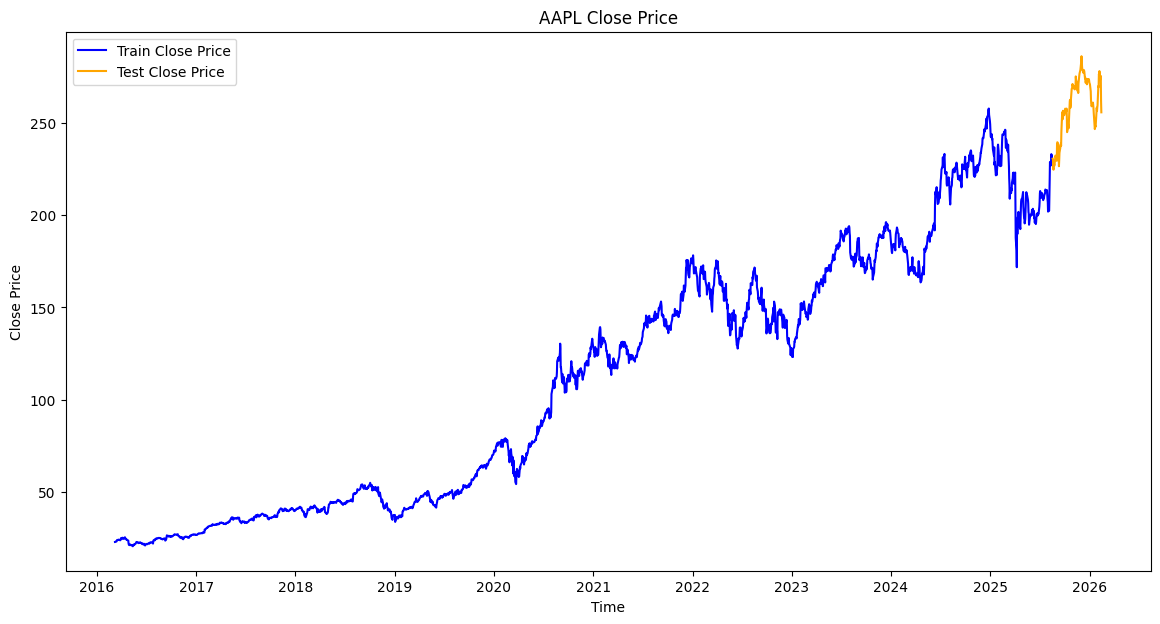

In [41]:
#plotar os dados
plt.figure(figsize=(14, 7))
plt.plot(train_df['time'], train_df['close'], label='Train Close Price', color='blue')
plt.plot(test_df['time'], test_df['close'], label='Test Close Price', color='orange')
plt.title(f'{symbol} Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [42]:
def create_fragments(close_diff, lag):
    X = []
    y = []
    for i in range(lag, len(close_diff)):
        X.append(close_diff[i-lag:i])
        y.append(close_diff[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

lag = 50
train_close_diff = train_df['close'].diff().dropna().values
test_close_diff = test_df['close'].diff().dropna().values

X_train, y_train = create_fragments(train_close_diff, lag)
X_test, y_test = create_fragments(test_close_diff, lag)

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError(f"Dados insuficientes para lag={lag}. Ajuste o lag ou aumente o tamanho das janelas.")

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"NaN em X_train? {np.isnan(X_train).any()} | NaN em y_train? {np.isnan(y_train).any()}")



X_train: (2324, 50), y_train: (2324,)
X_test: (74, 50), y_test: (74,)
NaN em X_train? False | NaN em y_train? False


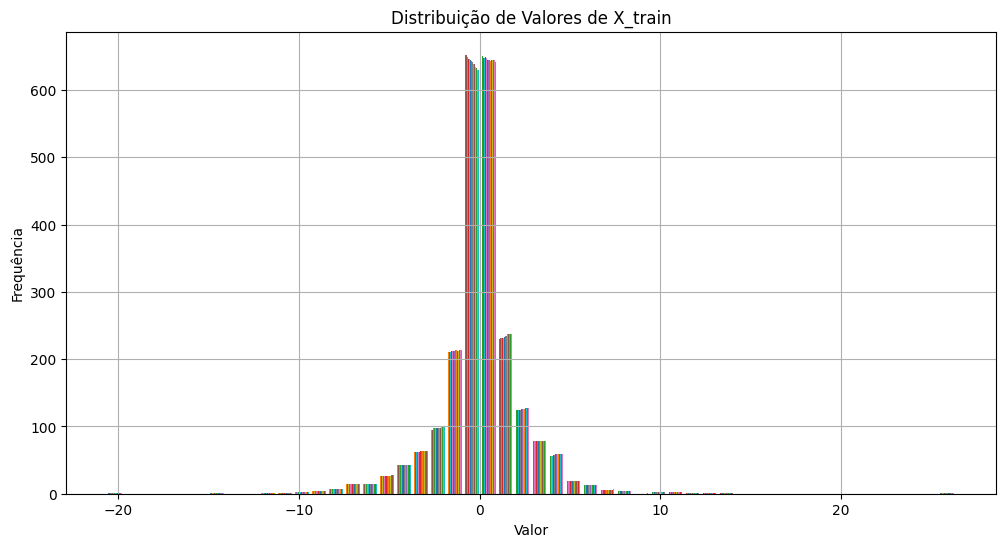

In [43]:
# plotar a distribuicao de valores de X_train
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(X_train , bins=50 )
plt.title('Distribuição de Valores de X_train')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.grid()
plt.show()

In [44]:
#inversão para tensores PyTorch

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [45]:
X_train

tensor([[[ 0.0218],
         [ 0.0119],
         [ 0.2444],
         ...,
         [ 0.7693],
         [-0.0904],
         [ 0.2455]],

        [[ 0.0119],
         [ 0.2444],
         [ 0.0591],
         ...,
         [-0.0904],
         [ 0.2455],
         [-0.0823]],

        [[ 0.2444],
         [ 0.0591],
         [ 0.4712],
         ...,
         [ 0.2455],
         [-0.0823],
         [ 0.2344]],

        ...,

        [[ 0.8480],
         [ 1.5670],
         [-0.4490],
         ...,
         [ 9.3000],
         [-1.9080],
         [ 2.4680]],

        [[ 1.5670],
         [-0.4490],
         [-2.1850],
         ...,
         [-1.9080],
         [ 2.4680],
         [ 3.6760]],

        [[-0.4490],
         [-2.1850],
         [ 3.2830],
         ...,
         [ 2.4680],
         [ 3.6760],
         [-0.5490]]])

In [46]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]
        logit = self.linear(last_out).squeeze(-1)
        return torch.tanh(logit)


In [47]:
model = SimpleLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
custo = 0.000001
epochs = 10

train_rewards = []
test_rewards = []

for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    model.train()
    optimizer.zero_grad()

    delta = model(X_train)
    delta_prev = F.pad(delta, [1, 0])[:-1]
    reward = delta_prev * y_train - custo * torch.abs(delta - delta_prev)

    if reward.numel() == 0:
        raise ValueError('Reward de treino vazio. Verifique lag, split e tamanho de X_train/y_train.')
    if not torch.isfinite(reward).all():
        raise ValueError('Reward de treino contém NaN/Inf. Verifique os dados de entrada e o pré-processamento.')

    loss = -reward.mean()
    loss.backward()
    optimizer.step()

    train_rewards.append(reward.mean().item())

    # Avaliação
    model.eval()
    with torch.no_grad():
        delta_test = model(X_test)
        delta_test_prev = F.pad(delta_test, [1, 0])[:-1]
        reward_test = delta_test_prev * y_test - custo * torch.abs(delta_test - delta_test_prev)

        if reward_test.numel() == 0:
            raise ValueError('Reward de teste vazio. Reduza o lag ou aumente o tamanho do conjunto de teste.')
        if not torch.isfinite(reward_test).all():
            raise ValueError('Reward de teste contém NaN/Inf. Verifique os dados de entrada e o pré-processamento.')

        test_rewards.append(reward_test.mean().item())

print('Resumo treino:')
print('  len(train_rewards)=', len(train_rewards), 'primeiros=', train_rewards[:3], 'ultimo=', train_rewards[-1])
print('  len(test_rewards)=', len(test_rewards), 'primeiros=', test_rewards[:3], 'ultimo=', test_rewards[-1])



Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
Resumo treino:
  len(train_rewards)= 10 primeiros= [-0.004528102930635214, -0.003557126736268401, -0.0025697159580886364] ultimo= 0.004933414049446583
  len(test_rewards)= 10 primeiros= [0.010334990918636322, 0.008087726309895515, 0.005799649748951197] ultimo= -0.01184930931776762


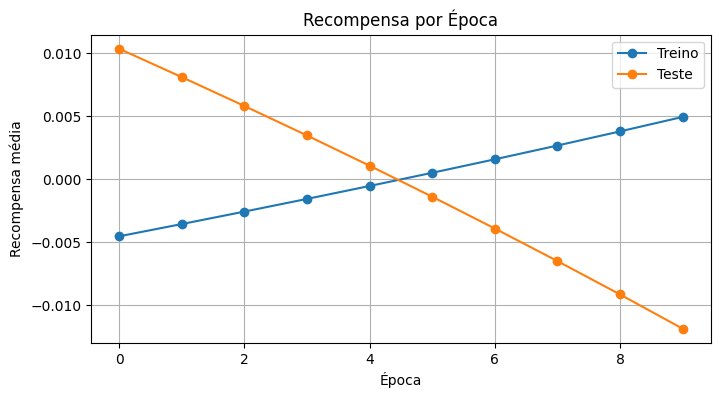

In [48]:
import numpy as np

if len(train_rewards) == 0 or len(test_rewards) == 0:
    raise ValueError('Listas de recompensa vazias. Rode a célula de treino antes do gráfico.')

train_arr = np.array(train_rewards, dtype=float)
test_arr = np.array(test_rewards, dtype=float)

if not np.isfinite(train_arr).all() or not np.isfinite(test_arr).all():
    raise ValueError('Recompensas com NaN/Inf. Reexecute pré-processamento + treino.')

plt.figure(figsize=(8, 4))
plt.plot(train_arr, marker='o', label='Treino')
plt.plot(test_arr, marker='o', label='Teste')
plt.title('Recompensa por Época')
plt.xlabel('Época')
plt.ylabel('Recompensa média')
plt.legend()
plt.grid(True)
plt.show()



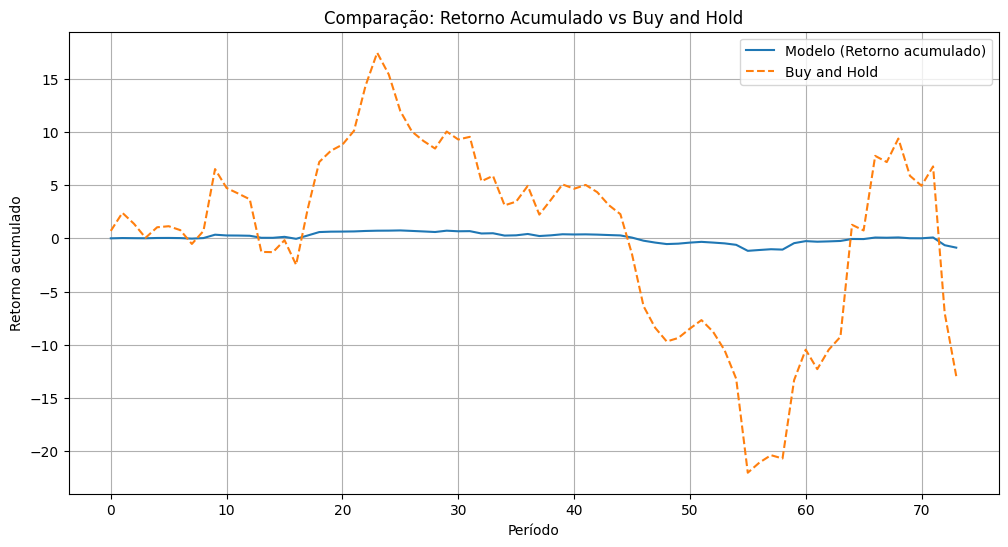

In [49]:
 
model.eval()
with torch.no_grad():
    # Decisões do modelo
    delta = model(X_test)
    delta_prev = F.pad(delta, [1, 0])[:-1]
    reward = delta_prev * y_test - custo * torch.abs(delta - delta_prev)
    ret_acumulado = torch.cumsum(reward, dim=0)

    # Benchmark Buy and Hold
    bnh = torch.cumsum(y_test, dim=0)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ret_acumulado.numpy(), label='Modelo (Retorno acumulado)')
plt.plot(bnh.numpy(), label='Buy and Hold', linestyle='--')
plt.title("Comparação: Retorno Acumulado vs Buy and Hold")
plt.xlabel("Período")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Retorno Long vs Short Fixos')

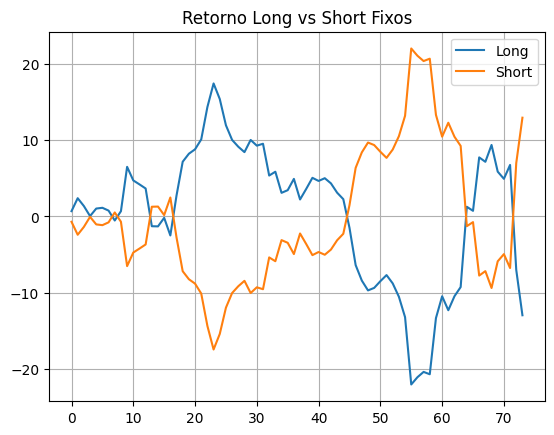

In [50]:
bnh_long = torch.cumsum(y_test, dim=0)
bnh_short = torch.cumsum(-y_test, dim=0)

plt.plot(bnh_long.numpy(), label='Long')
plt.plot(bnh_short.numpy(), label='Short')
plt.legend()
plt.grid()
plt.title("Retorno Long vs Short Fixos")